## Imports and jet class definition

### Imports

In [1]:
import numpy as np
import uproot as up
import awkward as ak

import matplotlib.pyplot as plt
import mplhep; mplhep.style.use("CMS")

### Jet class

In [2]:
class Jet:
    
    def __init__(self, path, where="test"):
        self.path = path
        if isinstance(path, dict):
            print("Dictionary of data received! Assigning data to attributes...")
            self.gen_pt = path["gen_pt"]
            self.reco_pt = path["reco_pt"]
            self.corr_pt = path["corr_pt"]

            self.gen_mass = path["gen_mass"]
            self.reco_mass = path["reco_mass"]
            self.corr_mass = path["corr_mass"]
        
        else:
            print(f"Loading data from {path}/...")
            
            if where == "test":
                self.gen_pt = np.load(f"{path}/testing_data/truth_pt_test.npy")
                self.reco_pt = np.load(f"{path}/testing_data/reco_pt_test.npy")
                self.corr_pt = self.reco_pt.copy()  # before applying corrections the reco pt is the same as the corrected pt

                self.gen_mass = np.load(f"{path}/testing_data/truth_mass_test.npy")
                self.reco_mass = np.load(f"{path}/testing_data/reco_mass_test.npy")
                self.corr_mass = self.reco_mass.copy()
            
            elif where == "train":
                data = up.concatenate(f"{path}/*.root:data", filter_name=["jet_pt_phys", "jet_genmatch_pt", "jet_mass", "jet_genmatch_mass"], how=dict, library="np")
                self.gen_pt = data["jet_genmatch_pt"]
                self.reco_pt = data["jet_pt_phys"]
                self.corr_pt = self.reco_pt.copy()

                self.gen_mass = data["jet_genmatch_mass"]
                self.reco_mass = data["jet_mass"]
                self.corr_mass = self.reco_mass.copy()
            
            elif where == "raw":
                branches = ["jet_pt_phys", "jet_pt", "jet_pt_raw", "jet_genmatch_pt", "jet_genmatch_lep_vis_pt", "jet_mass", "jet_genmatch_mass"]
                data = up.concatenate(f"{path}:outnano/Jets", filter_name=branches, how=dict, library="np")
                self.gen_pt = data["jet_genmatch_pt"]
                self.reco_pt = data["jet_pt_phys"]
                self.corr_pt = self.reco_pt.copy()

                self.gen_mass = data["jet_genmatch_mass"]
                self.reco_mass = data["jet_mass"]
                self.corr_mass = self.reco_mass.copy()
            
            else:
                raise ValueError(f"Unknown data type {where}!")
            
            self.nJets = len(self.gen_pt)

    def get_corr(self, external_model=None, sfs=False):
        # Load model and get num of inputs and outputs
        if external_model is not None:
            print(f"Loading external model...")
            self.model = external_model
        else:
            self.model = Jet.get_model(self.path)
        N_inputs = len(self.model.inputs)
        
        # Load inputs to the model
        inputs = Jet.load_inputs(self.path, N_inputs)

        # Pass inputs to the model to get predictions
        preds = Jet.make_predictions(self.model, inputs)

        # Reshape predictions to match reco inputs and set attribute
        for idx, out in enumerate(self.model.outputs):
            varname = out.name.split("_")[0]
            if varname == "pT": self.corr_pt = self.reco_pt * preds[idx].reshape(self.reco_pt.shape) if sfs else preds[idx].reshape(self.reco_pt.shape)    # preset attr names
            elif varname == "mass": self.corr_mass = self.reco_mass * preds[idx].reshape(self.reco_mass.shape) if sfs else preds[idx].reshape(self.reco_mass.shape)  # preset attr names
            else: raise ValueError(f"Unknown variable name {varname} in model output {out.name}!")            

    @staticmethod
    def get_model(path):
        print(f"Loading model from {path}/model/...")
        from qkeras.utils import load_qmodel
        model = load_qmodel(f"{path}/model/saved_model.h5")
        # from keras.models import load_model
        # model = load_model(f"{path}/model/saved_model.h5")
        print(f"Loaded model {model.name} requiring {[i.name for i in model.inputs]}")
        return model

    @staticmethod
    def load_inputs(path, N_inputs=2):
        """
        Loads inputs to model from the specified path.
        If the model requires only constituent inputs, loads them from the path.
        If the model requires both constituent and jet inputs, checks if jet inputs are present and returns both if available.
        """
        if N_inputs == 1:
            print(f"Model requires only constituent inputs, loading constituent inputs from {path}/testing_data/...")
            constituents = np.load(f"{path}/testing_data/X_test_constits.npy")
            return constituents
        elif N_inputs == 2:
            print(f"Model requires both constituent and jet inputs, checking if jet inputs are present...")
            from os.path import isfile
            if isfile(f"{path}/testing_data/X_test_jets.npy"):
                print(f"Jet inputs present! Loading constituent and jet inputs from {path}/testing_data/...")
                constituents = np.load(f"{path}/testing_data/X_test_constits.npy")
                jets = np.load(f"{path}/testing_data/X_test_jets.npy")
                return constituents, jets
            else:
                print(f"Jet inputs NOT present! Exiting...")
                raise FileNotFoundError(f"Jet inputs not found in {path}/testing_data/X_test_jets.npy")
        else: 
            raise ValueError(f"Model requires either 1 or 2 inputs, but {N_inputs} were provided!")

    @staticmethod
    def make_predictions(model, inputs):
        """
        Makes predictions from passed inputs and model.
        Will always return predictions as a list for upstream iterating.
        """
        print("Making predictions...")
        preds = model.predict(inputs)
        if not isinstance(preds, list): preds = [preds]
        return preds

    def visualise(self, nBins=50, range_=(2000, 500)):
        fig, axs = plt.subplots(1, 3, figsize=(36, 12), facecolor="white")
        ax1, ax2, ax3 = axs
        
        ptlim, masslim = range_

        plot1 = ax1.hist2d(self.reco_pt, self.reco_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], cmap='viridis')
        plot2 = ax2.hist2d(self.corr_pt, self.corr_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], cmap='viridis')
        plot3 = ax3.hist2d(self.gen_pt, self.gen_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], cmap='viridis')
        
        vmin = 1
        vmax = max(plot1[0].max(), plot2[0].max())

        # Replot with the same color scale
        ax1.clear()
        ax2.clear()
        ax3.clear()
        from matplotlib.colors import LogNorm
        plot1 = ax1.hist2d(self.reco_pt, self.reco_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], norm=LogNorm(vmin=vmin, vmax=vmax), cmap='viridis')
        plot2 = ax2.hist2d(self.corr_pt, self.corr_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], norm=LogNorm(vmin=vmin, vmax=vmax), cmap='viridis')
        plot3 = ax3.hist2d(self.gen_pt, self.gen_mass, bins=nBins, range=[[0, ptlim], [0, masslim]], norm=LogNorm(vmin=vmin, vmax=vmax), cmap='viridis')
        
        fig.colorbar(plot1[3], ax=ax1, label="Density (log scale)", pad=0.01)
        fig.colorbar(plot2[3], ax=ax2, label="Density (log scale)", pad=0.01)
        fig.colorbar(plot3[3], ax=ax3, label="Density (log scale)", pad=0.01)
        
        ax1.grid(); ax2.grid(); ax3.grid()
        
        ax1.legend(loc="upper left")
        ax1.set_xlabel("Reco pT (GeV)", fontsize=24); ax2.set_xlabel("Corrected pT (GeV)", fontsize=24); ax3.set_xlabel("Gen pT (GeV)", fontsize=24)
        ax1.set_ylabel("Reco mass (GeV)", fontsize=24); ax2.set_ylabel("Corrected mass (GeV)", fontsize=24); ax3.set_ylabel("Gen mass (GeV)", fontsize=24)
        
        xt, yt = np.linspace(0, ptlim, 7), np.linspace(0, masslim, 9)
        ax1.set_xticks(xt); ax2.set_xticks(xt); ax3.set_xticks(xt)
        ax1.set_yticks(yt); ax2.set_yticks(yt); ax3.set_yticks(yt)
        
        plt.show()

    def __len__(self):
        return len(self.gen_pt)
    
    def _bin(self, bins, var):
        gen = getattr(self, f"gen_{var}")
        reco = getattr(self, f"reco_{var}")
        corr = getattr(self, f"corr_{var}")
        reco_resp, corr_resp = reco/gen, corr/gen
        reco_mean, corr_mean, reco_std, corr_std = [], [], [], []
        reco_mean_errs, corr_mean_errs, reco_std_errs, corr_std_errs = [], [], [], []
        counts_li = []
        for b in range(len(bins)-1):
            # Get mask for the bin
            mask = (gen >= bins[b]) & (gen < bins[b+1])
            reco_resp_inBin, corr_resp_inBin = reco_resp[mask], corr_resp[mask]
            counts_li.append( np.sum(mask) )

            # Means and standard deviations
            reco_mean.append(np.mean(reco_resp_inBin))
            corr_mean.append(np.mean(corr_resp_inBin))
            reco_std.append(np.std(reco_resp_inBin))
            corr_std.append(np.std(corr_resp_inBin))

            # Errors
            reco_mean_errs.append( np.std(reco_resp_inBin) / np.sqrt(len(reco_resp_inBin)) )
            corr_mean_errs.append( np.std(corr_resp_inBin) / np.sqrt(len(corr_resp_inBin)) )
            reco_std_errs.append( np.std(reco_resp_inBin) / np.sqrt(2*(len(reco_resp_inBin)-1)) )
            corr_std_errs.append( np.std(corr_resp_inBin) / np.sqrt( 2*(len(corr_resp_inBin)-1) ) )
        
        xs, xerrs = ((bins/2)[1] + bins)[:-1], np.diff(bins)/2

        return xs, xerrs, reco_mean, reco_mean_errs, reco_std, reco_std_errs, corr_mean, corr_mean_errs, corr_std, corr_std_errs, counts_li

    def plot_response(self, *vars_):
        _, axes = plt.subplots(2, max(2, len(vars_)), figsize=(24,24), facecolor="white")
        for idx, var in enumerate(vars_):
            bins, var = var
            tickdensity = 5
            xs, xerrs, reco_mean, reco_mean_errs, reco_std, reco_std_errs, corr_mean, corr_mean_errs, corr_std, corr_std_errs, counts = self._bin(bins, var)
            ax_std, ax_mean = axes[idx]

            scaledCounts = ( counts / max(counts) )
            ax_std.bar(xs, scaledCounts, width=2*xs[0], alpha=0.2, color="tab:grey")
            ax_mean.bar(xs, scaledCounts*2, width=2*xs[0], alpha=0.2, color="tab:grey")
            
            # ax_std.errorbar(xs, corr_std, xerr=xerrs, label=f"Corr {var}", fmt="o-", capsize=5, yerr=corr_std_errs)
            # ax_std.errorbar(xs, reco_std, xerr=xerrs, label=f"Reco {var}", fmt="o-", capsize=5, yerr=reco_std_errs)
            # ax_mean.errorbar(xs, corr_mean, xerr=xerrs, label=f"Corr {var}", fmt="o-", capsize=5, yerr=corr_mean_errs)
            # ax_mean.errorbar(xs, reco_mean, xerr=xerrs, label=f"Reco {var}", fmt="o-", capsize=5, yerr=reco_mean_errs)
            ax_std.errorbar(xs, corr_std, label=f"Corr {var}", fmt="-", capsize=0)
            ax_std.errorbar(xs, reco_std, label=f"Reco {var}", fmt="-", capsize=0)
            ax_mean.errorbar(xs, corr_mean, label=f"Corr {var}", fmt="-", capsize=0)
            ax_mean.errorbar(xs, reco_mean, label=f"Reco {var}", fmt="-", capsize=0)
            
            # Conditional formatting as string formatting doesnt work with latex
            if var == "mass":
                ax_std.set_xlabel("$Mass_{gen} (GeV)$"); ax_std.set_ylabel("$\sigma( \\frac{Mass_{online}}{Mass_{gen}} )$")
                ax_mean.set_xlabel("$Mass_{gen}$ (GeV)"); ax_mean.set_ylabel("$\mu( \\frac{Mass_{online}}{Mass_{gen}} )$")
            elif var == "pt":
                ax_std.set_xlabel("$p_{T, gen}$ (GeV)"); ax_std.set_ylabel("$\sigma( \\frac{p_{T, online}}{p_{T, gen}} )$")
                ax_mean.set_xlabel("$p_{T, gen}$ (GeV)"); ax_mean.set_ylabel("$\mu( \\frac{p_{T, online}}{p_{T, gen}} )$")
            else: raise ValueError(f"Unknown variable {var}!")

            ax_std.axhline(0, linestyle="--", color="grey", label="Perfect precision")
            ax_std.set_ylim([-0.05, 1.05])
            ax_std.set_xticks(bins[::tickdensity])
            ax_std.legend()
            ax_std.grid()
            ax_mean.axhline(1, linestyle="--", color="grey", label="Perfect accuracy")
            ax_mean.set_ylim([-0.1, 2.1])
            ax_mean.set_xticks(bins[::tickdensity])
            ax_mean.legend()
            ax_mean.grid()

        plt.show()

## Binned corrections

In [3]:
class Corrector():
    
    def __init__(self, path, ptvar, etavar, branch="outnano/Jets"):
        self.data = up.open(path)[branch]
        self.ptvar = ptvar
        self.etavar = etavar

    def load(self):
        print(f"Loading L1 data with pt == {self.ptvar} and eta == {self.etavar}...")
        self.l1 = np.array( [self.data[f"jet_{self.ptvar}"].array(), self.data[f"jet_{self.etavar}"].array(), self.data["jet_mass"].array()] ).T
        print(f"L1 data loaded.\n")
        
        print(f"Loading gen data...")
        self.gen = np.array( [self.data["jet_genmatch_pt"].array(), self.data["jet_genmatch_eta"].array(), self.data["jet_genmatch_mass"].array()] ).T
        print(f"Gen data loaded.\n")
        
        print(f"Rejecting jets marked as bad...")
        reject_mask = self.data["jet_reject"].array() == False
        self.l1, self.gen = self.l1[reject_mask], self.gen[reject_mask]
        print(f"Rejected { np.sum( reject_mask == False ) } jets marked as bad.")
        
        self.total = len(self.l1)
        self.nJets = self.total
        self.isShuffled = False
        print(f"Total jets = {self.total}\n\n")
        return self.l1, self.gen

    def filterUnmatched(self):
        """ Removed unmatched jets """
        genmatch_mask = (self.gen[:,0] > 15) & (self.gen[:,2] > 5)
#         genmatch_mask = (self.gen[:,0] > 0) & (self.gen[:,2] > 0)
        print(f"Removing {self.total - np.sum(genmatch_mask)} unmatched jets in dataset...")
        self.l1, self.gen = self.l1[genmatch_mask], self.gen[genmatch_mask]
        print(f"{len(self.gen)} jets remaining in dataset\n\n")
        self.nJets = np.sum(genmatch_mask)
        return self.l1, self.gen

    def l1cuts(self, ptcut = 15, etacut = 2.4, masscut = 5):
        """ Apply basic kinematic cuts """
        cuts_mask = (self.l1[:, 0] > ptcut) & (np.abs(self.l1[:, 1]) < etacut) & (self.l1[:,2] > masscut)
        print(f"Removing {self.nJets - np.sum(cuts_mask)} jets due to level-1 cuts...")
        self.l1, self.gen = self.l1[cuts_mask], self.gen[cuts_mask]
        print(f"{len(self.gen)} jets remaining in dataset.\n\n")
        return self.l1, self.gen
    
    def preprocess(self):
        mask = self.gen[:,2] > 1
        self.l1, self.gen = self.l1[mask], self.gen[mask]
        self.l1[:,2] = np.clip(self.l1[:,2], 0, 182)
        
    def shuffle(self):
        print(f"Shuffling jets...")
        shuffle = np.random.permutation(len(self.l1))
        self.l1, self.gen = self.l1[shuffle], self.gen[shuffle]
        self.isShuffled = True
        print(f"Jets shuffled.\n\n")
        return self.l1, self.gen
    
    def split(self, train_ratio = 0.75):
        print(f"Splitting jets into training and testing samples...")
        splitIdx = int(len(self.l1) * train_ratio)
        self.l1_train, self.l1_test = self.l1[:splitIdx], self.l1[splitIdx:]
        self.gen_train, self.gen_test = self.gen[:splitIdx], self.gen[splitIdx:]
        print(f"Allocated {len(self.l1_train)} jets for training, and {len(self.l1_test)} jets for testing\n\n")
        return self.l1_train, self.l1_test, self.gen_train, self.gen_test
    
    def response(self):
        print(f"Calculating pT and mass response...")
        pt_response = self.l1_train[:,0] / self.gen_train[:,0]
        mass_response = self.l1_train[:,2] / self.gen_train[:,2]
        self.l1_train = np.hstack([self.l1_train, pt_response[:,None], mass_response[:,None]])
        print(f"pT and mass response calculated and appended to data.\n")
    
    def histogram(self, nBins=31, nan=1):
        from scipy.stats import binned_statistic_dd
        bins = [nBins, nBins, nBins]
        print("Binning with respect to gen pT, eta and mass, with bins populated with mean pT response and mean mass response...")
        pt_resp, _, _ = binned_statistic_dd( self.l1_train[:, [0,1,2]], self.l1_train[:, 3], statistic='mean', bins = bins )
        mass_resp, edges, _ = binned_statistic_dd( self.l1_train[:, [0,1,2]], self.l1_train[:, 4], statistic='mean', bins = bins )
        print("Binning complete.\n")
        
        print(f"Calculating scale factors from mean response, imputing 1 for nans...")
        self.pt_sf = 1 / np.nan_to_num(pt_resp, nan=nan)
        self.mass_sf = 1 / np.nan_to_num(mass_resp, nan=nan)
        self.bin_edges = edges
        
        print(f"Scale factors saved.\n\n")
        return pt_resp, mass_resp, edges
    
    def applyScaleFactors(self):
        print(f"Applying scale factors to get corrected pT and mass...")
        bin_idx = [np.digitize(self.l1_test[:, i], self.bin_edges[i]) - 1 for i in range(3)]    # assume first three indices are pt, eta and mass
        bin_idx = np.stack(bin_idx, axis=-1)

        # check that jet falls into a valid, predefined bin
        valid = np.all( [(0 <= bin_idx[:, i]) & (bin_idx[:, i] < len(self.bin_edges[i]) - 1) for i in range(3)], axis=0 )

        # initialize output and assign values from mean_values
        pt_output, mass_output = np.ones( len(self.l1_test) ), np.ones( len(self.l1_test) )
        pt_output[valid] = self.pt_sf[ tuple(bin_idx[valid].T) ]    # where jet falls into a valid bin, assign the scale factor
        mass_output[valid] = self.mass_sf[ tuple(bin_idx[valid].T) ]    # where jet falls into a valid bin, assign the scale factor
        
        pt_corr = self.l1_test[:,0] * pt_output
        mass_corr = self.l1_test[:,2] * mass_output
        
        self.l1_test = np.hstack( [self.l1_test, pt_corr[:,None], mass_corr[:,None]] )
        print(f"Corrected pT and mass saved.\n\n")
        return pt_corr, mass_corr
    
    def _build(self):
        print(f"Producing a dataframe from test data...")
        d = np.hstack([self.l1_test[:,[0,2,3,4]], self.gen_test[:,[0,2]]])

        d = {
            "reco_pt": d[:,0],
            "reco_mass": d[:,1],
            "corr_pt": d[:,2],
            "corr_mass": d[:,3],
            "gen_pt": d[:,4],
            "gen_mass": d[:,5]
        }

        return d

    def pipeline(self):
        self.load()
        self.filterUnmatched()
        self.l1cuts()
        self.preprocess()
        self.shuffle()
        self.split()
        self.response()
        self.histogram()
        self.applyScaleFactors()

        return self._build()

In [4]:
binned = Corrector("TrainTagger/sc8Jets.root", "pt", "eta_phys")

In [47]:
binned_corrs = Jet(path=binned.pipeline())

Loading L1 data with pt == pt and eta == eta_phys...
L1 data loaded.

Loading gen data...
Gen data loaded.

Rejecting jets marked as bad...
Rejected 18462 jets marked as bad.
Total jets = 7815073


Removing 2102690 unmatched jets in dataset...
5712383 jets remaining in dataset


Removing 1347175 jets due to level-1 cuts...
4365208 jets remaining in dataset.


Shuffling jets...
Jets shuffled.


Splitting jets into training and testing samples...
Allocated 3273906 jets for training, and 1091302 jets for testing


Calculating pT and mass response...
pT and mass response calculated and appended to data.

Binning with respect to gen pT, eta and mass, with bins populated with mean pT response and mean mass response...
Binning complete.

Calculating scale factors from mean response, imputing 1 for nans...
Scale factors saved.


Applying scale factors to get corrected pT and mass...
Corrected pT and mass saved.


Producing a dataframe from test data...
Dictionary of data received! Assigning da

/tmp/lroberts/ipykernel_3508510/1673835637.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left")


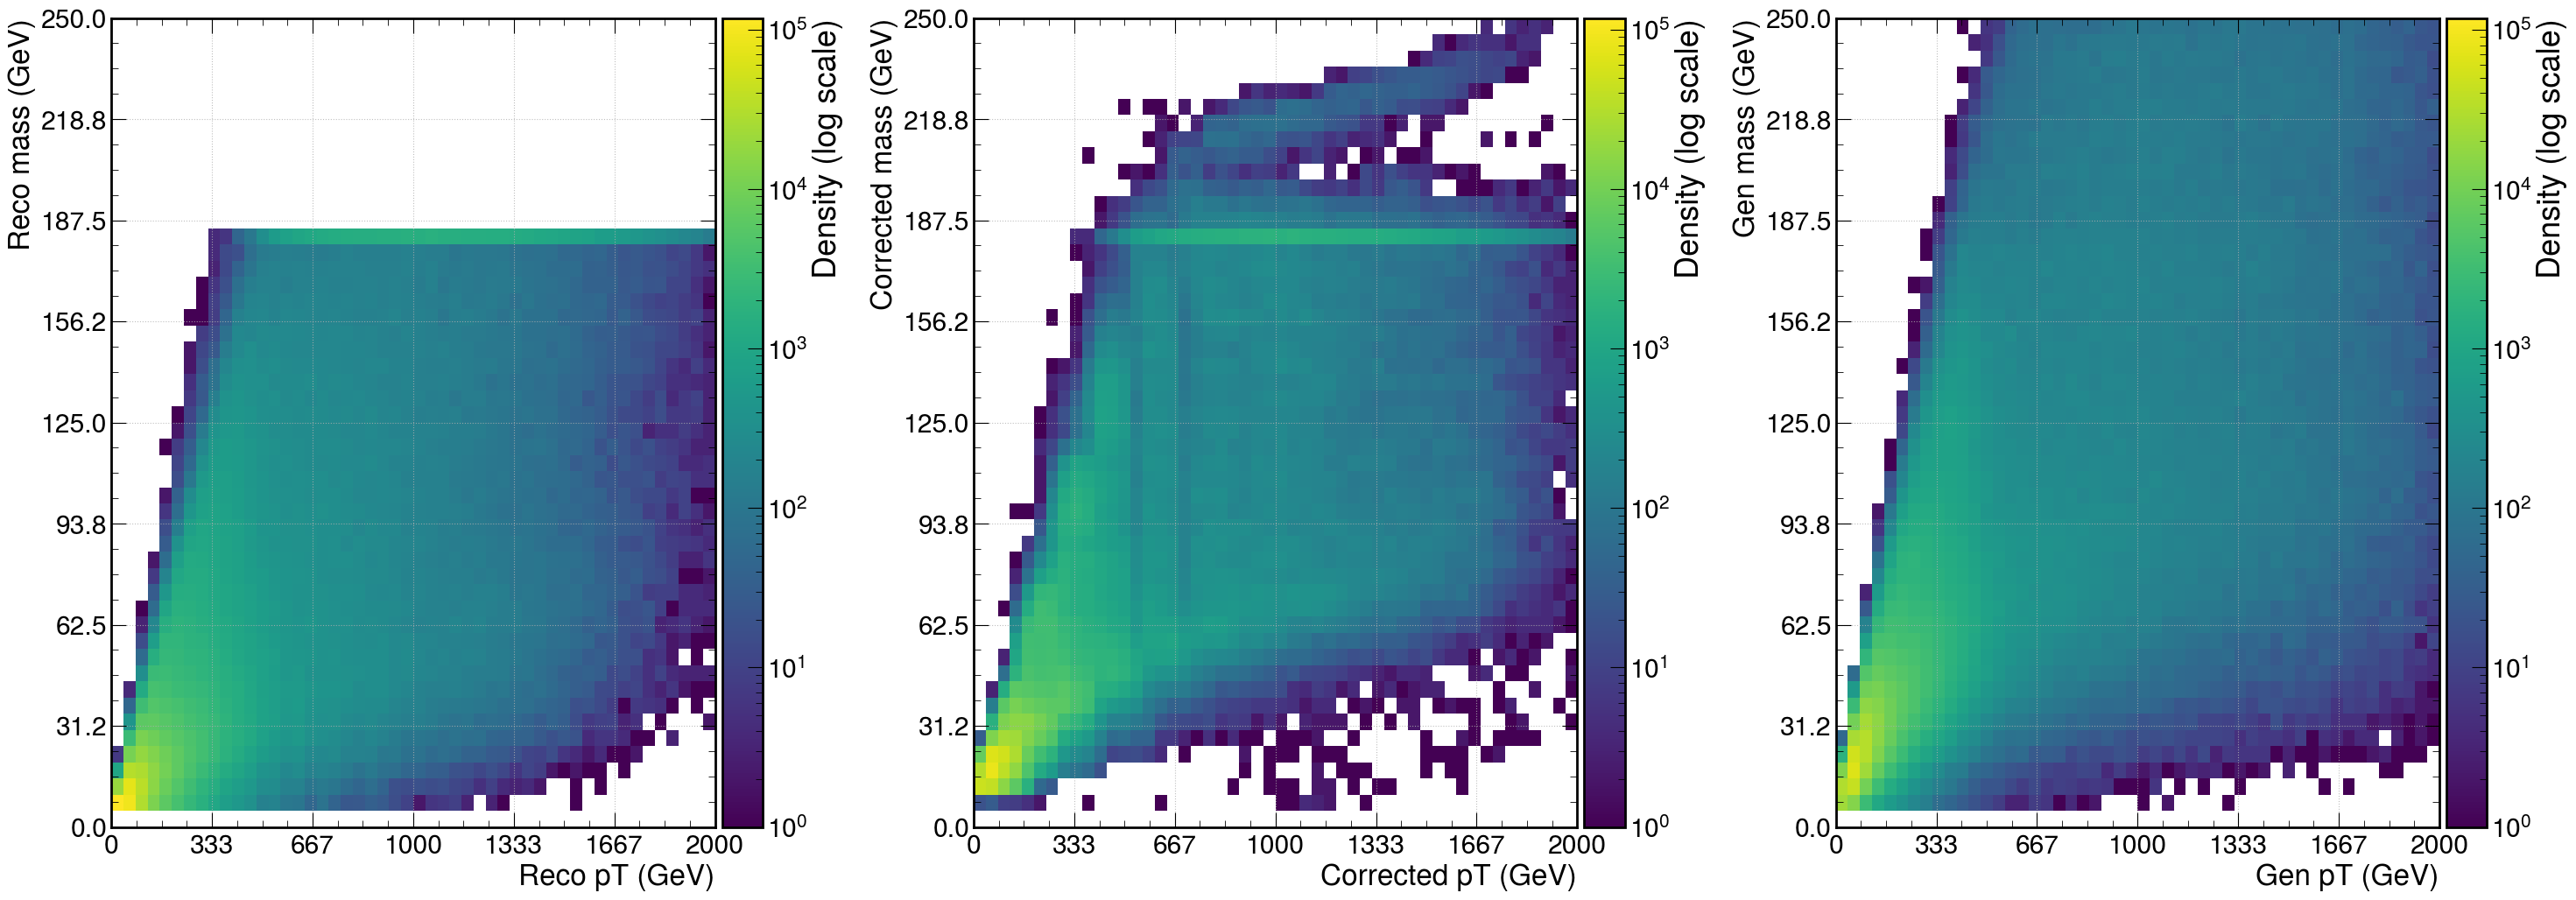

In [48]:
binned_corrs.visualise(range_=(2000, 250))

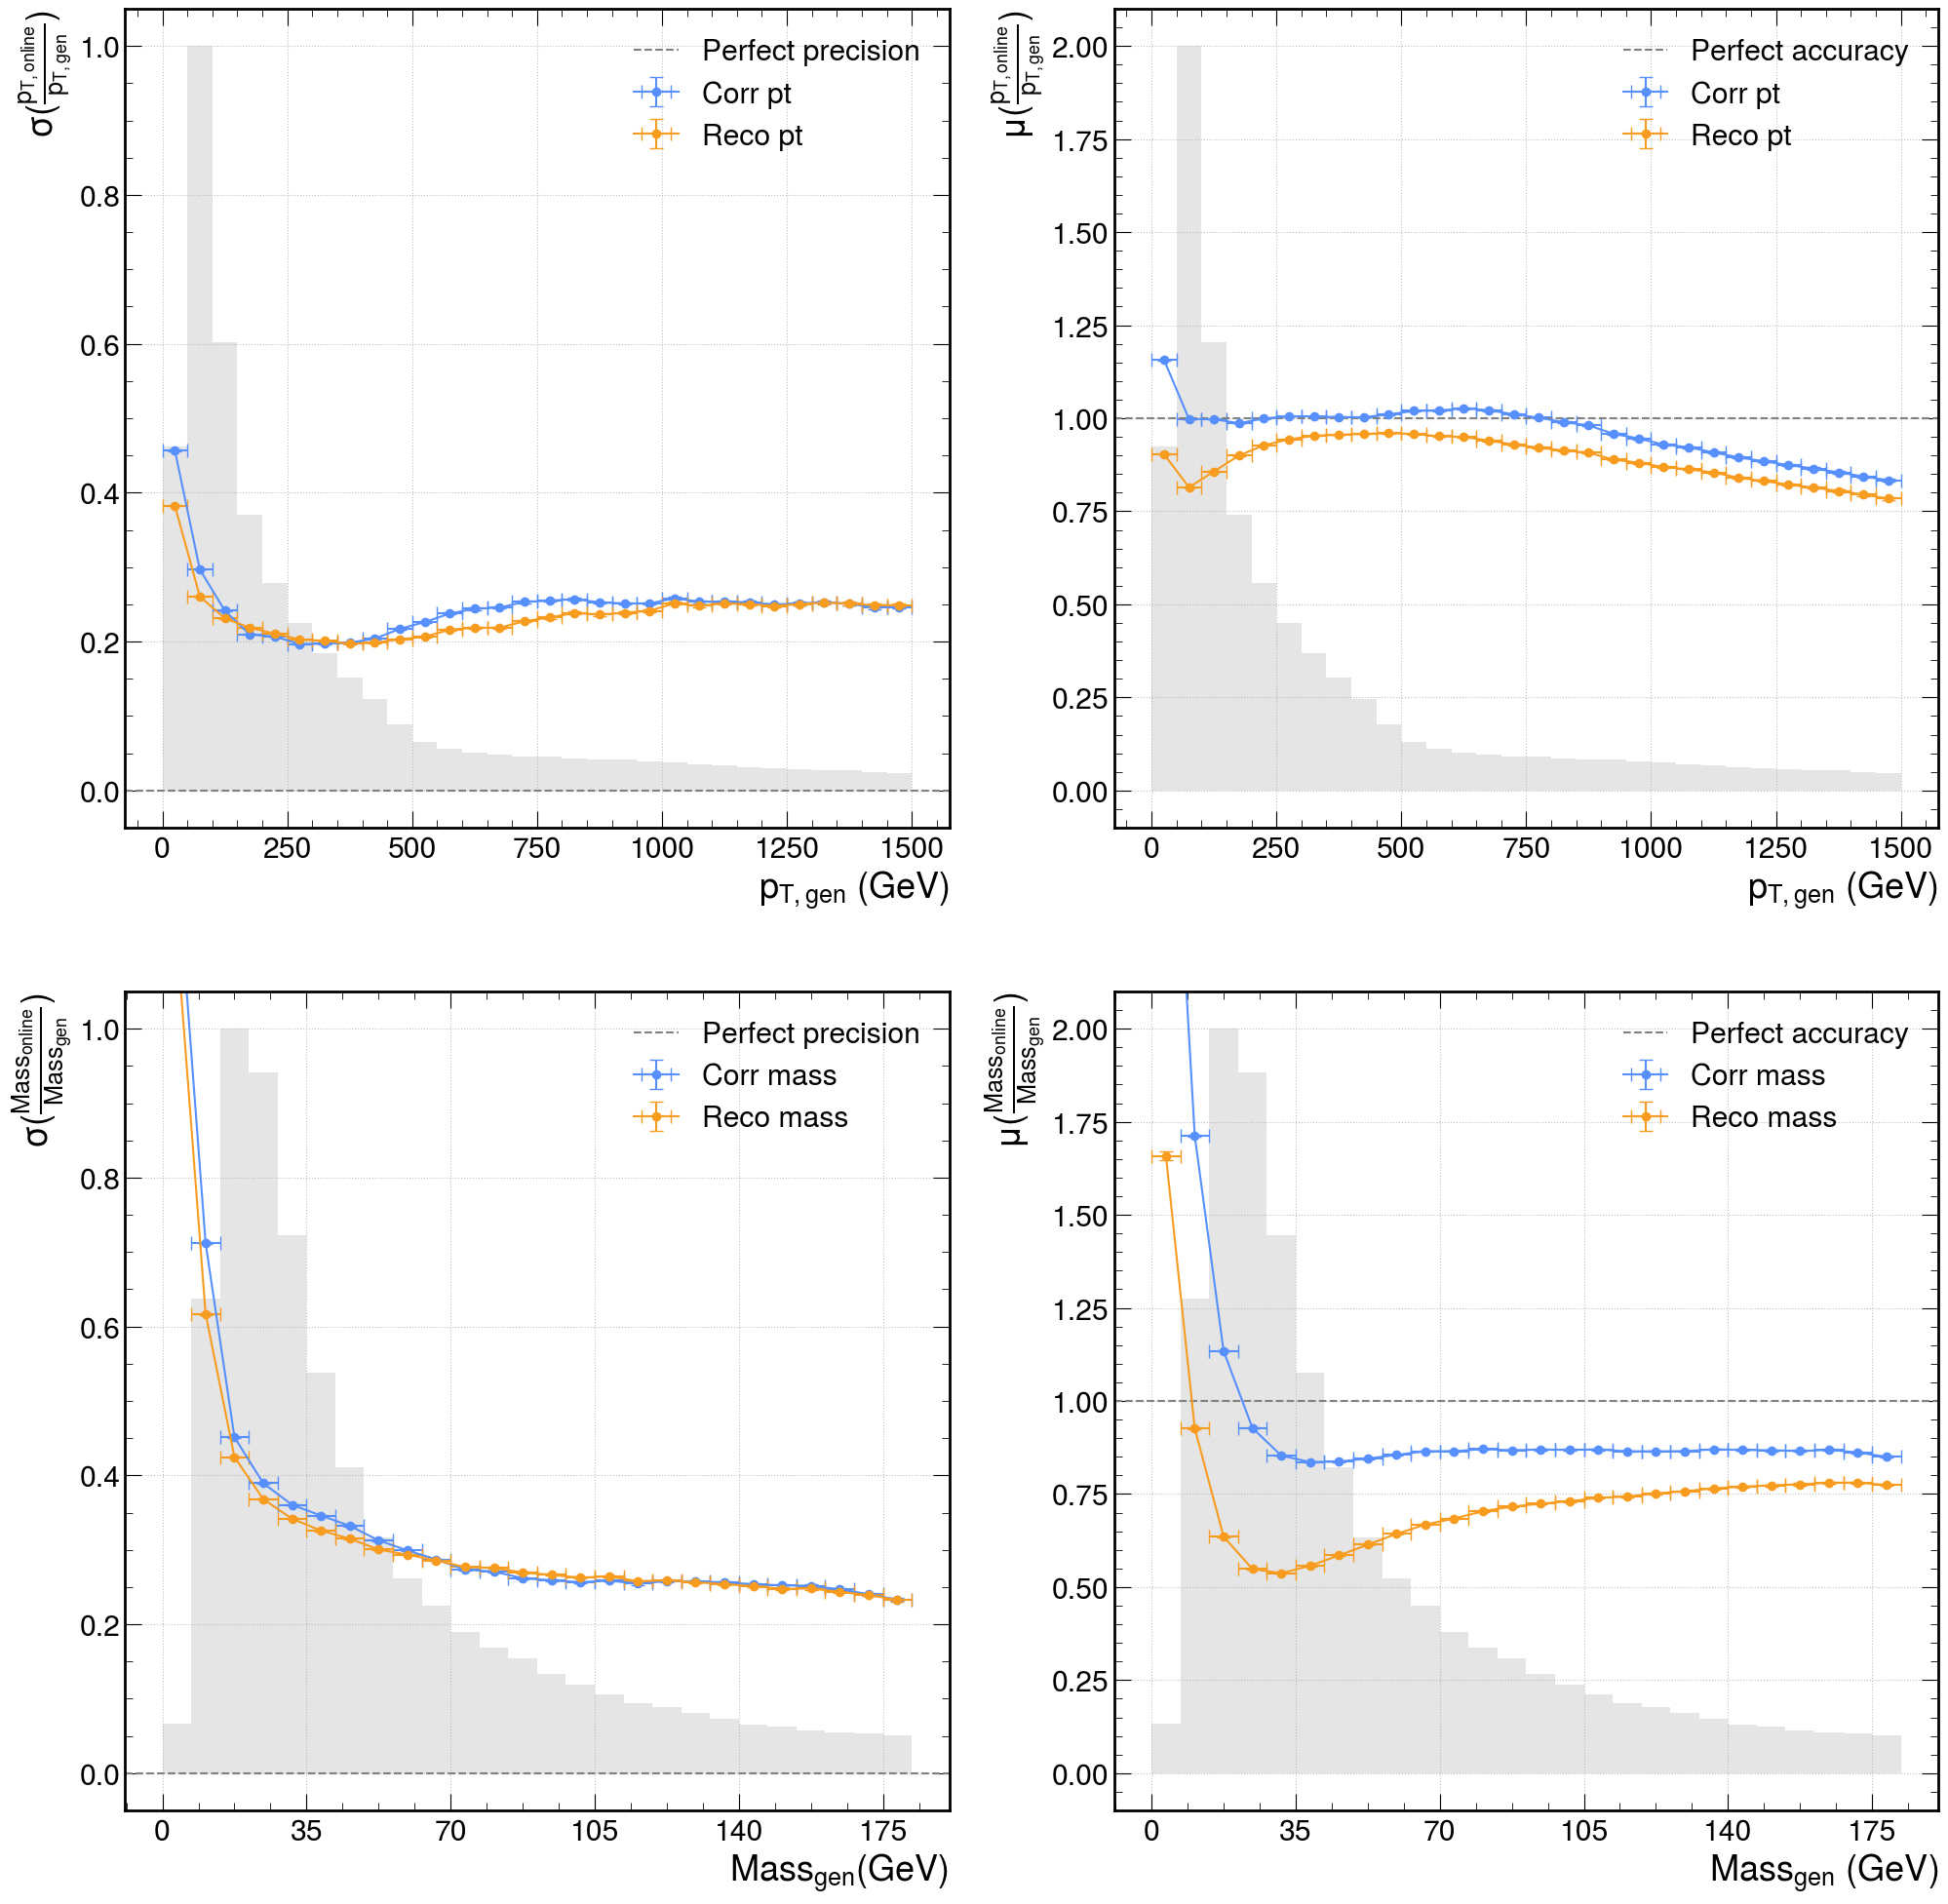

In [49]:
binned_corrs.plot_response(  (np.linspace(0, 1500, 31), "pt"), (np.linspace(0, 182, 27), "mass") )

## Deepset corrections

#### Load signal data and model

In [3]:
test = Jet("output/qbaseline_moreepochs", where="test")

Loading data from output/qbaseline_moreepochs/...


In [4]:
test.get_corr(sfs=True)

Loading model from output/qbaseline_moreepochs/model/...


2025-06-16 11:22:18.504545: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 11:22:18.547886: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-16 11:22:18.547937: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-16 11:22:18.547969: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-16 11:22:18.556638: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 11:22:18.557318: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Loaded model qbaseline requiring ['constituent_inputs', 'jet_inputs']
Model requires both constituent and jet inputs, checking if jet inputs are present...
Jet inputs present! Loading constituent and jet inputs from output/qbaseline_moreepochs/testing_data/...
Making predictions...
20462/20462 [==============================] - 21s 1ms/step


/tmp/ipykernel_454176/2034156272.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left")


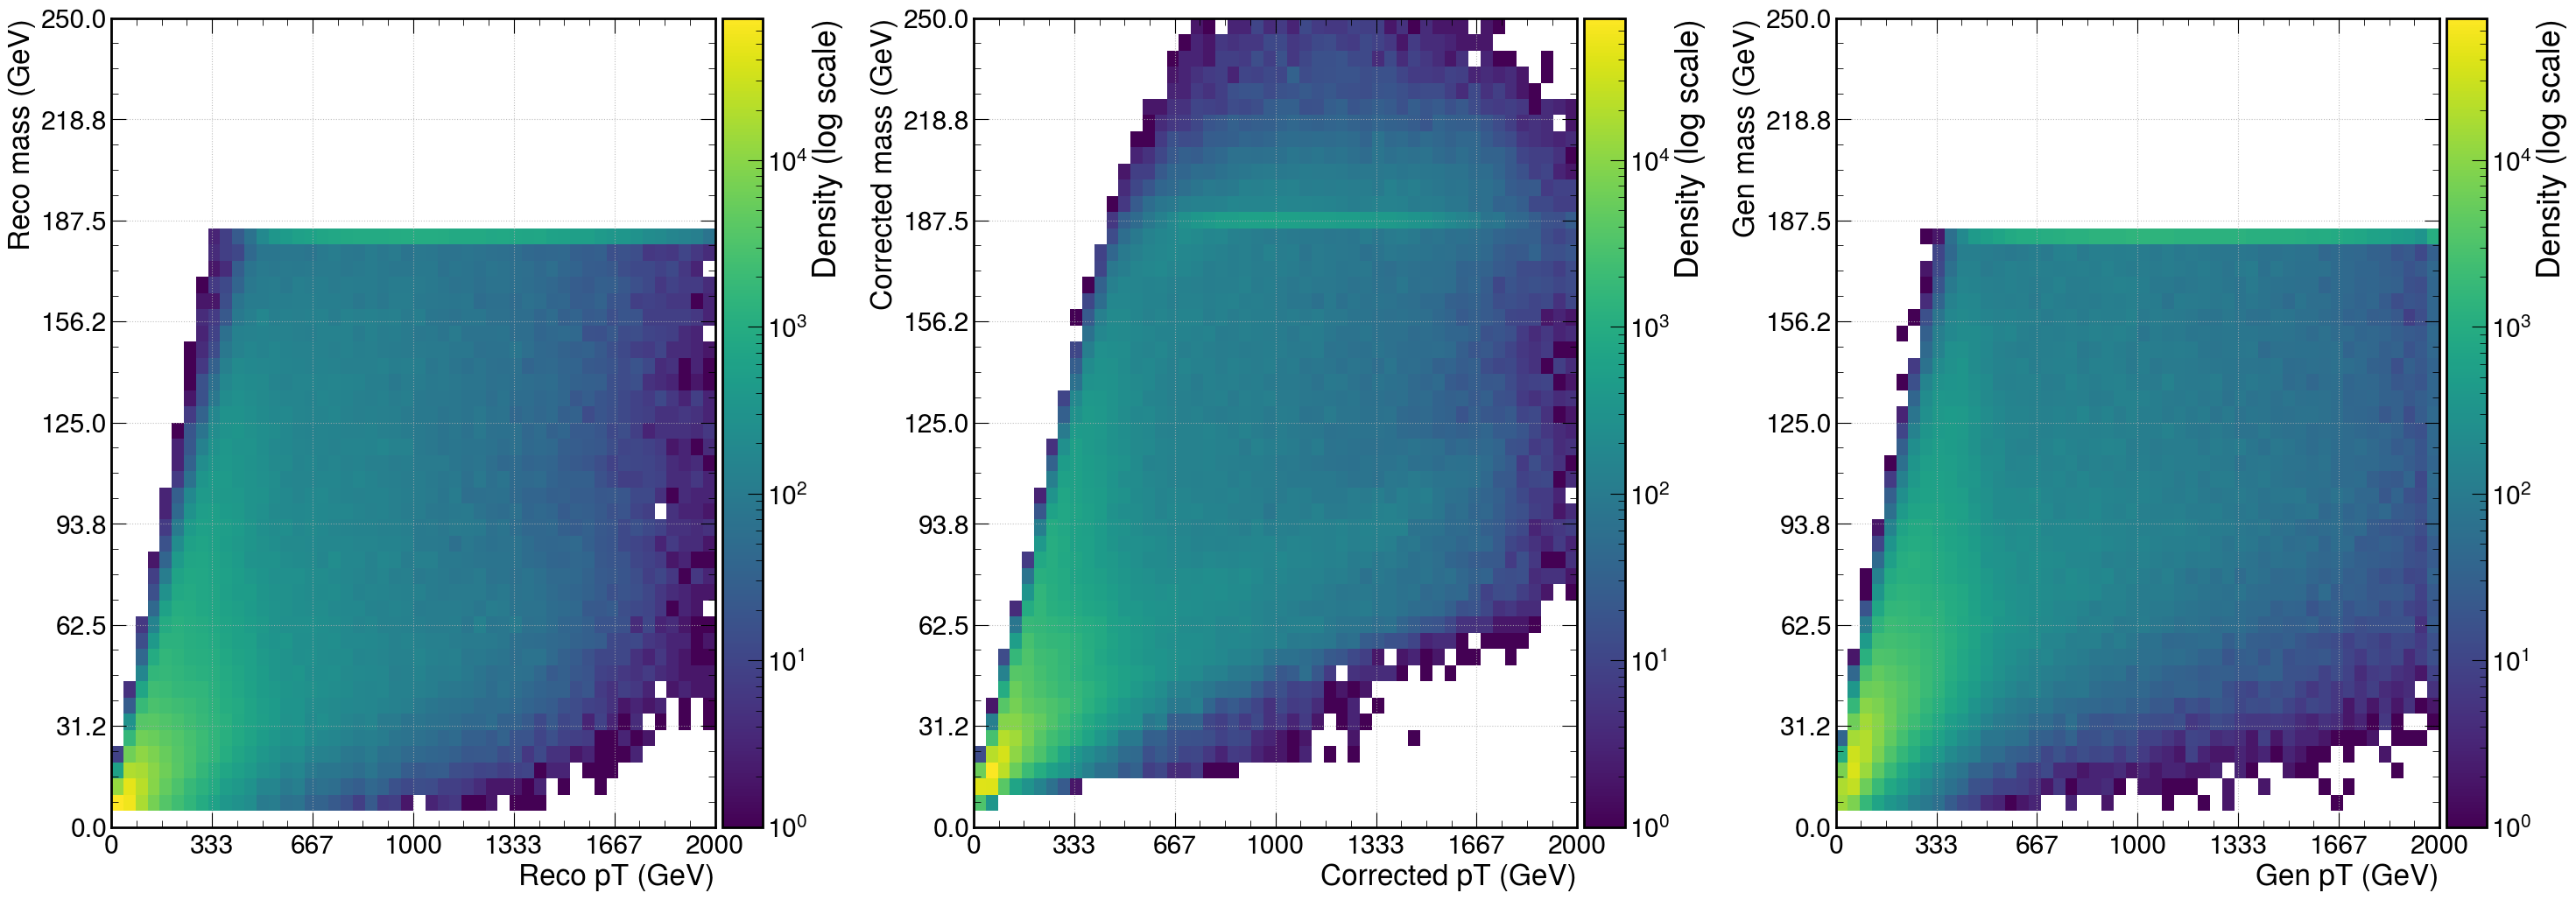

In [5]:
test.visualise( nBins=50, range_=(2000, 250) )

/software/wq22321/miniconda/envs/tagger/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/software/wq22321/miniconda/envs/tagger/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/software/wq22321/miniconda/envs/tagger/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/software/wq22321/miniconda/envs/tagger/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/software/wq22321/miniconda/envs/tagger/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_454176/2034156

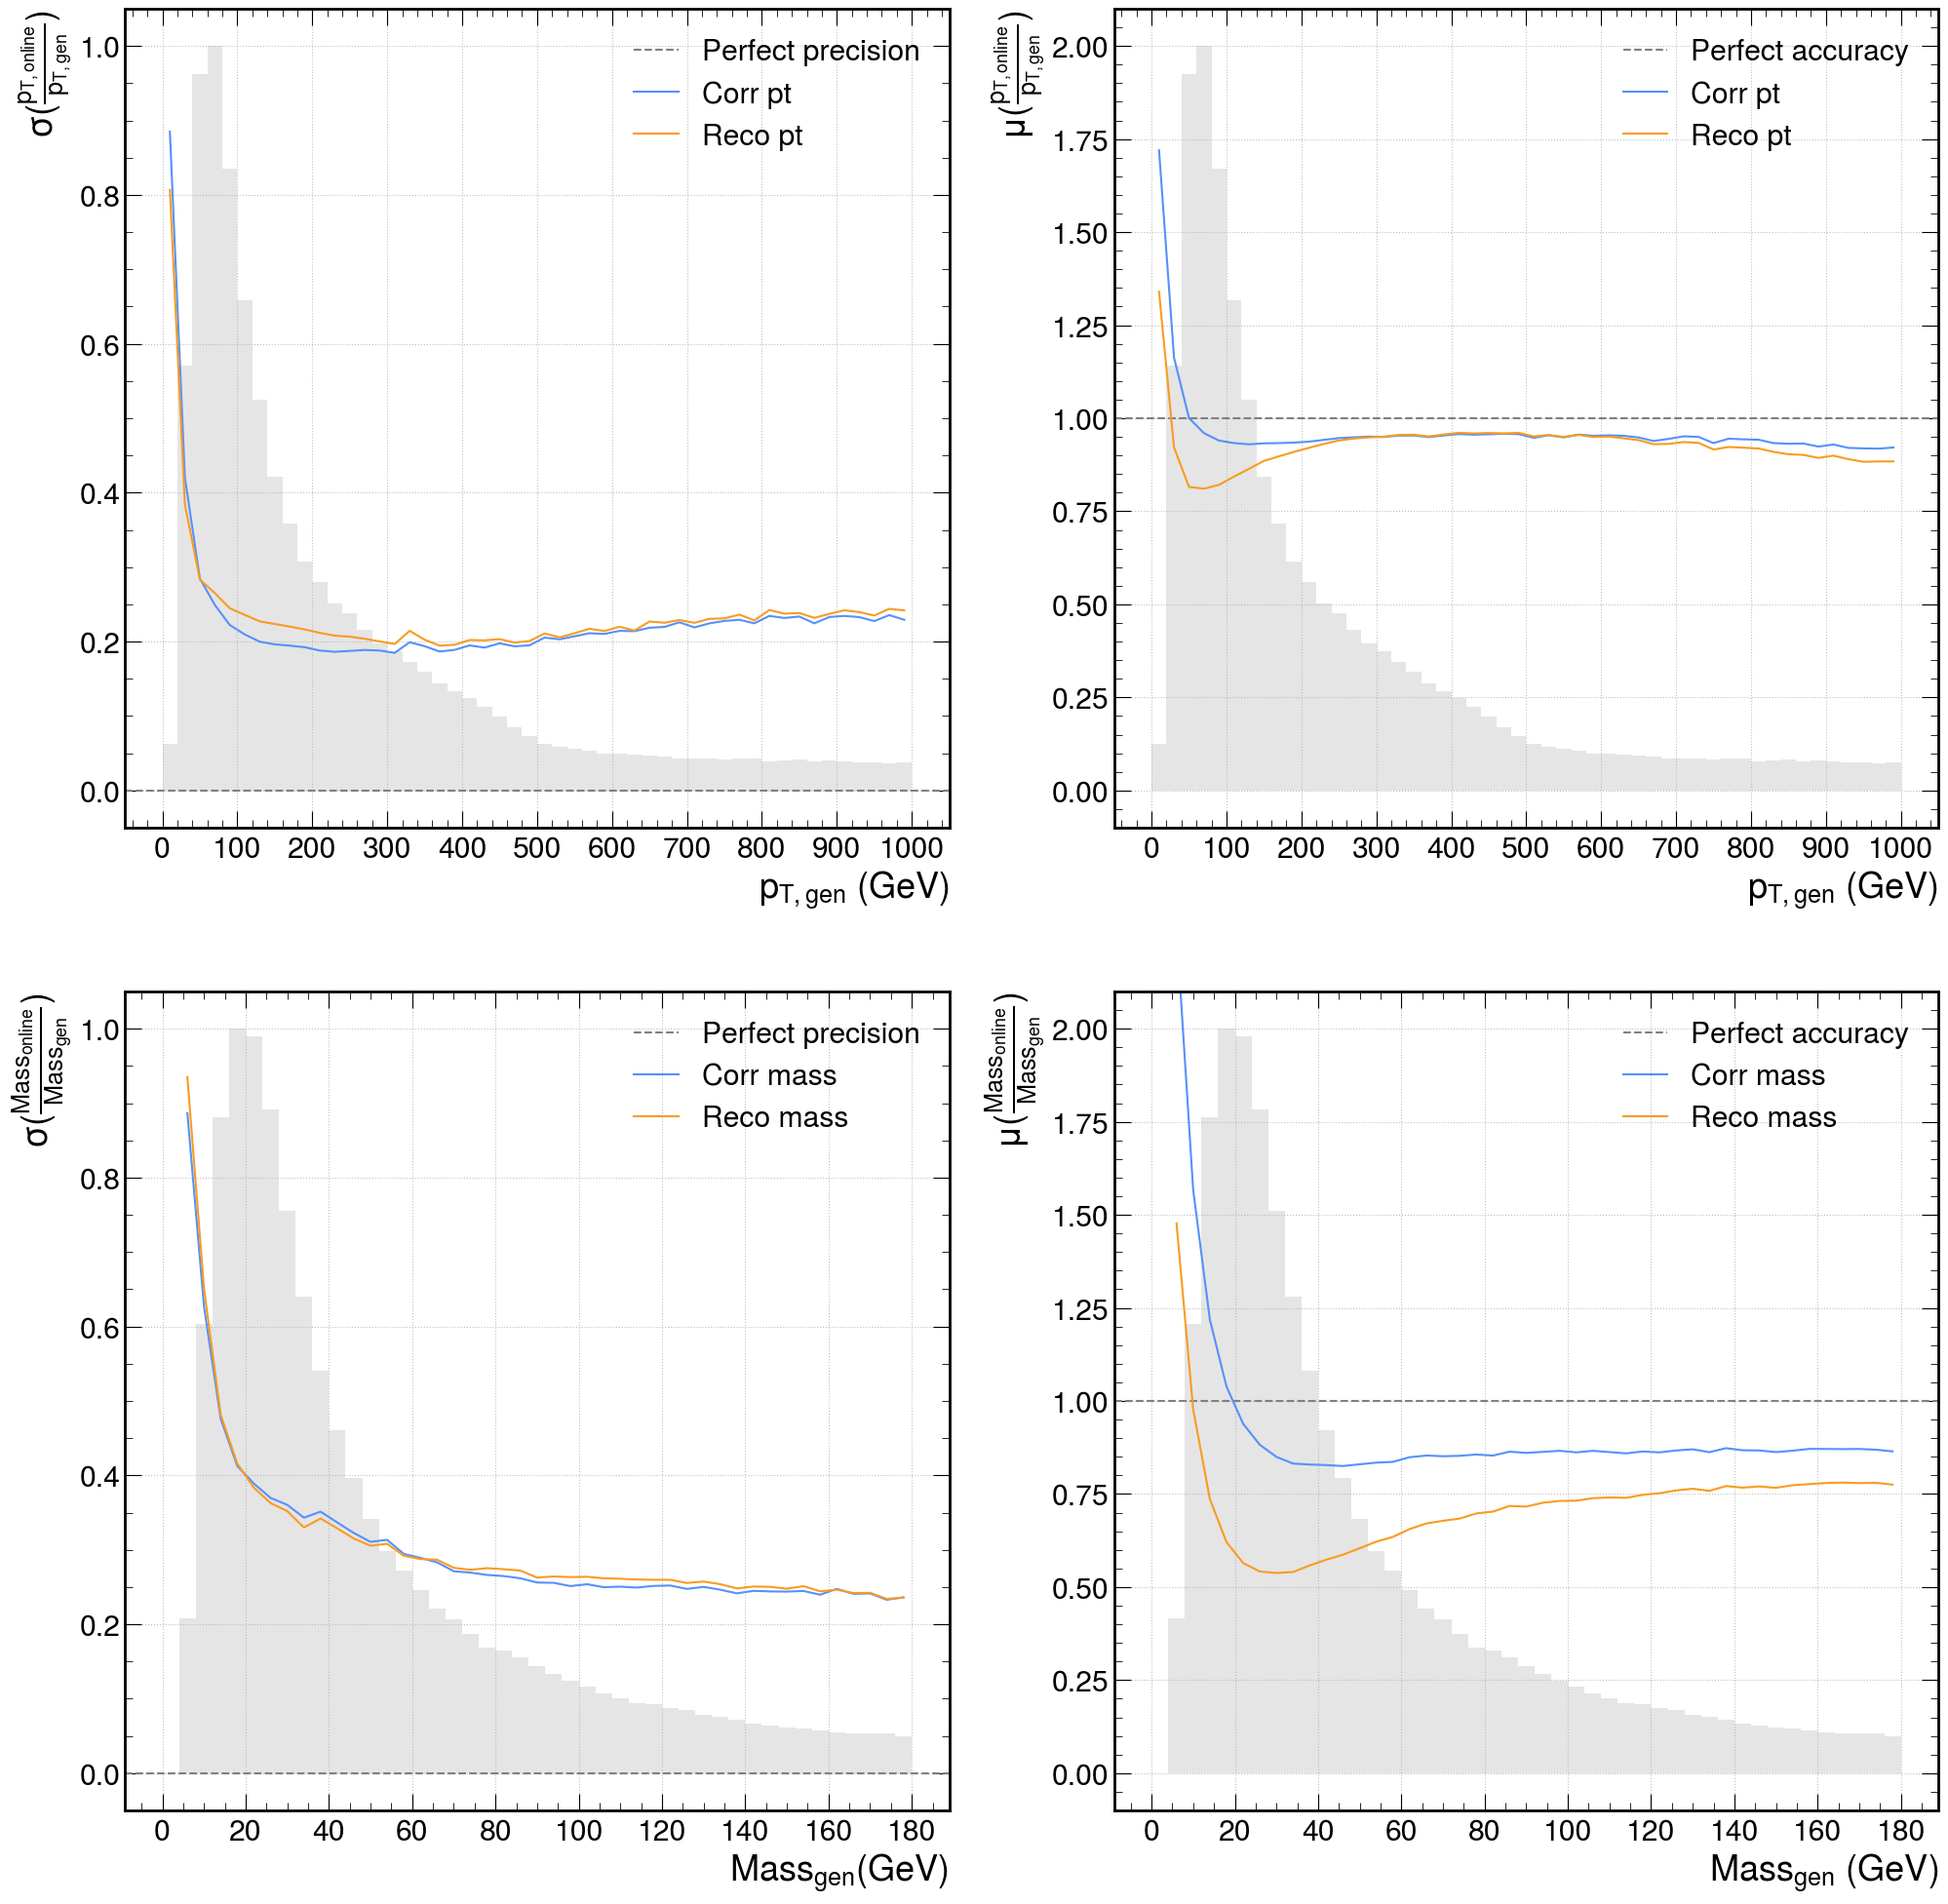

In [6]:
test.plot_response( (np.linspace(0, 1000, 51), "pt"), (np.linspace(0, 180, 46), "mass") )

## Fixed-rate efficiency

In [9]:
# Need background data to calculate rate, must be in format that model can process
bkg_path = "/eos/home-l/lroberts/mass_regression/CMSSW_14_2_0_pre2/src/TrainTagger/bkg_data"

In [10]:
bkg = Jet(bkg_path)

Loading data from /eos/home-l/lroberts/mass_regression/CMSSW_14_2_0_pre2/src/TrainTagger/bkg_data/...


FileNotFoundError: [Errno 2] No such file or directory: '/eos/home-l/lroberts/mass_regression/CMSSW_14_2_0_pre2/src/TrainTagger/bkg_data/testing_data/truth_pt_test.npy'

In [12]:
bkg.get_corr(test.model, sfs=True)

Loading external model...
Model requires both constituent and jet inputs, checking if jet inputs are present...
Jet inputs present! Loading constituent and jet inputs from /eos/home-l/lroberts/mass_regression/CMSSW_14_2_0_pre2/src/TrainTagger/bkg_data/testing_data/...
Making predictions...
51585/51585 [==============================] - 63s 1ms/step


/tmp/lroberts/ipykernel_1355987/1964863875.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left")


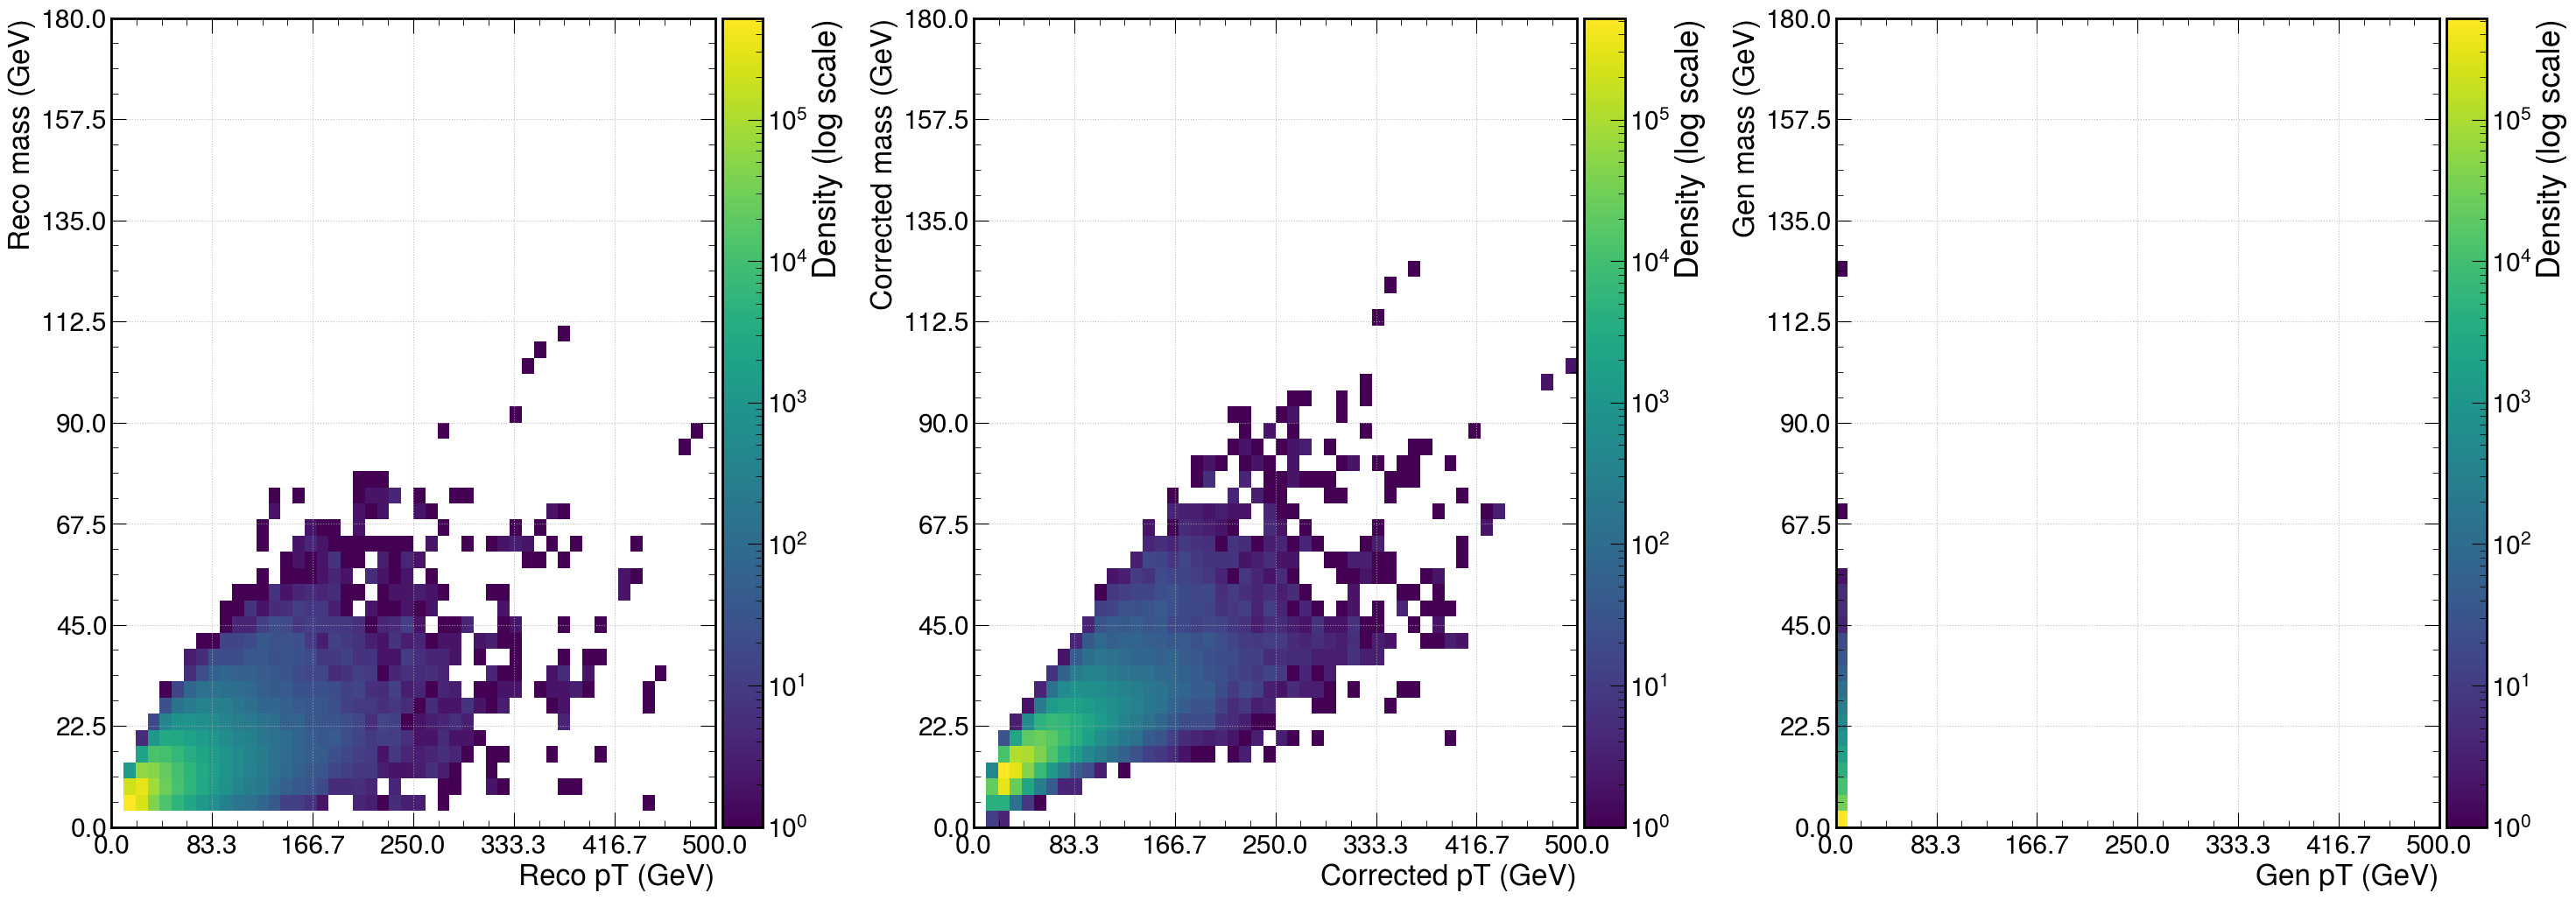

In [13]:
bkg.visualise(range_=(500, 180))

In [14]:
def optimum_cuts(cuts, sig, bkg, purity, corr=False):
    pt_cut, mass_cut = cuts
    if corr == False:
        if ( np.sum( (bkg.reco_pt > pt_cut) | (bkg.reco_mass > mass_cut) ) / len(bkg) ) > purity: return 999
        else: return -1 * ( np.sum( (sig.reco_pt > pt_cut) | (sig.reco_mass > mass_cut) ) / len(sig) )   # percent of signal jets passing
    elif corr == True:
        if ( np.sum( (bkg.corr_pt > pt_cut) | (bkg.corr_mass > mass_cut) ) / len(bkg) ) > purity: return 999
        else: return -1 * ( np.sum( (sig.corr_pt > pt_cut) | (sig.corr_mass > mass_cut) ) / len(sig) )   # p
    else: raise Exception("corr must be True or False")

In [15]:
from scipy.optimize import differential_evolution
purity = 0.005
opti_reco = differential_evolution(optimum_cuts, bounds = [(0, 500), (0, 200)], args=(test, bkg, purity, False), seed=42)
opti_corr = differential_evolution(optimum_cuts, bounds = [(0, 500), (0, 200)], args=(test, bkg, purity, True), seed=42)

In [20]:
def fteff(jets, param="pt"):

    if param == "pt":
        bins = np.linspace(0, 300, 31)
        gen = jets.gen_pt
    elif param == "mass":
        bins = np.linspace(0, 120, 21)
        gen = jets.gen_mass
    
    reco_effs, corr_effs, counts = [], [], []
    for b in range(len(bins)-1):
        mask = (gen >= bins[b]) & (gen < bins[b+1])
        denominator = np.sum(mask)
        counts.append(denominator)
        
        reco_pt_cut, reco_mass_cut = opti_reco.x
        l1_reco_cut = (jets.reco_pt[mask] >= reco_pt_cut) | (jets.reco_mass[mask] >= reco_mass_cut)
        reco_effs.append( np.sum(l1_reco_cut) / denominator if denominator > 0 else 0 )

        corr_pt_cut, corr_mass_cut = opti_corr.x
        l1_corr_cut = (jets.corr_pt[mask] >= corr_pt_cut) | (jets.corr_mass[mask] >= corr_mass_cut)
        corr_effs.append( np.sum(l1_corr_cut) / denominator if denominator > 0 else 0 )
    
    return bins, reco_effs, corr_effs, counts

In [47]:
def plot_fteff(jets, param="pt"):
    plt.figure(figsize=(15, 10), facecolor="white")

    bins, reco_effs, corr_effs, counts = fteff(jets, param)

    xs = bins[:-1] + np.diff(bins) / 2
    scaledCounts = ( counts / max(counts) )
    plt.bar(xs, scaledCounts, width=2*xs[0], alpha=0.2, color="tab:grey")

    cross_corr, cross_reco = np.interp(0.95, corr_effs, xs), np.interp(0.95, reco_effs, xs)
    plt.axvline(cross_corr, color='tab:blue', linestyle='--')
    plt.axvline(cross_reco, color='tab:orange', linestyle='--')

    plt.errorbar(xs[1:], corr_effs[1:], fmt="-o", xerr=xs[0], label=f"Corr, 95% eff: {cross_corr:.1f} GeV", color="tab:blue")
    plt.errorbar(xs[1:], reco_effs[1:], fmt="-o", xerr=xs[0], label=f"Reco, 95% eff: {cross_reco:.1f} GeV", color="tab:orange")

    plt.axhline( y=0.95, color='black', linestyle='--', label="95% efficiency" )
    if param == "pt": plt.xlabel("Gen $p_T$ (GeV)", fontsize=24)
    else: plt.xlabel("Gen mass (GeV)", fontsize=16)
    plt.ylabel("Online efficiency @ 0.5% background", fontsize=24)
    plt.xticks(bins[::2], fontsize=20)
    plt.yticks(np.linspace(0, 1, 11), fontsize=20)
    plt.xlim([bins[0] - xs[0], bins[-1] + xs[0]]); plt.ylim([-0.05, 1.05])
    plt.legend(fontsize=20, loc="center left") #, loc="lower right"
    plt.grid()
    plt.show()

    return xs, reco_effs

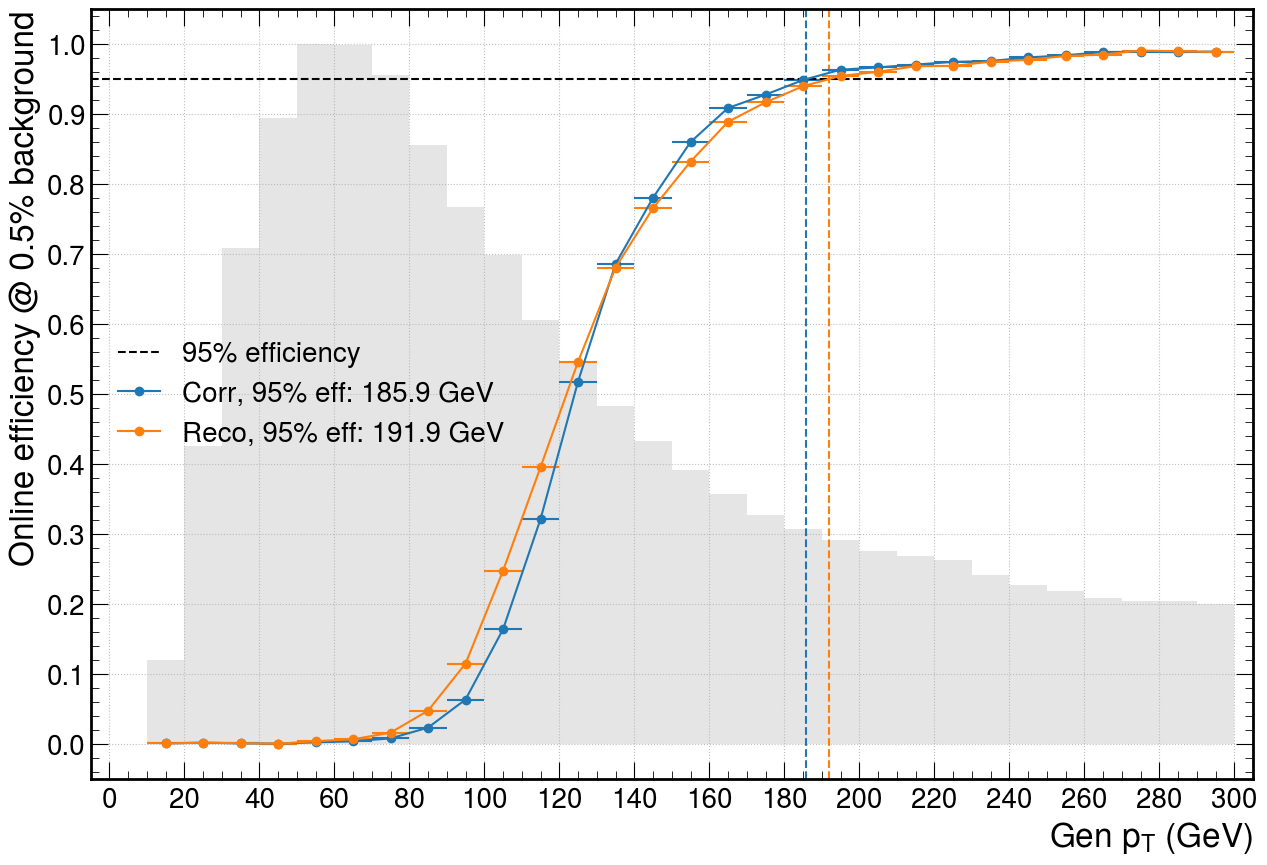

In [48]:
b, effs = plot_fteff(test, "pt")

In [53]:
d = up.open("training_data_with_Epxpypz/data_chunk_900.root:data")

In [58]:
arr = np.asarray( d["nn_inputs"] )

In [78]:
a = arr[:, :, :-4 ]

In [82]:
a[0].shape

(32, 20)